# Day 25 — Model Evaluation & Selection
### Learning Curves · Bias-Variance · Cross-Validation Strategies · Model Comparison

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    validation_curve,
    StratifiedKFold,
    LeaveOneOut,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

Train: (712, 9) | Test: (179, 9)
Ready! ✅


## 2. Bias-Variance Tradeoff

       BIAS-VARIANCE TRADEOFF

BIAS: Error from wrong assumptions in the model
  High bias → model too SIMPLE → UNDERFITTING
  Misses real patterns in data
  Both train AND test accuracy are low

VARIANCE: Error from sensitivity to training data
  High variance → model too COMPLEX → OVERFITTING
  Memorises training data, fails on new data
  Train accuracy high, test accuracy much lower

THE TRADEOFF:
  Simple model:  High Bias,    Low Variance
  Complex model: Low Bias,     High Variance
  Goal:          Find the sweet spot in between!

TOTAL ERROR = Bias² + Variance + Irreducible Noise

EXAMPLES:
  Decision Tree (depth=None): Low bias, HIGH variance
  Decision Tree (depth=2):    HIGH bias, low variance
  Decision Tree (depth=3):    BALANCED ✅
  Random Forest:              Low bias, LOW variance (best!)



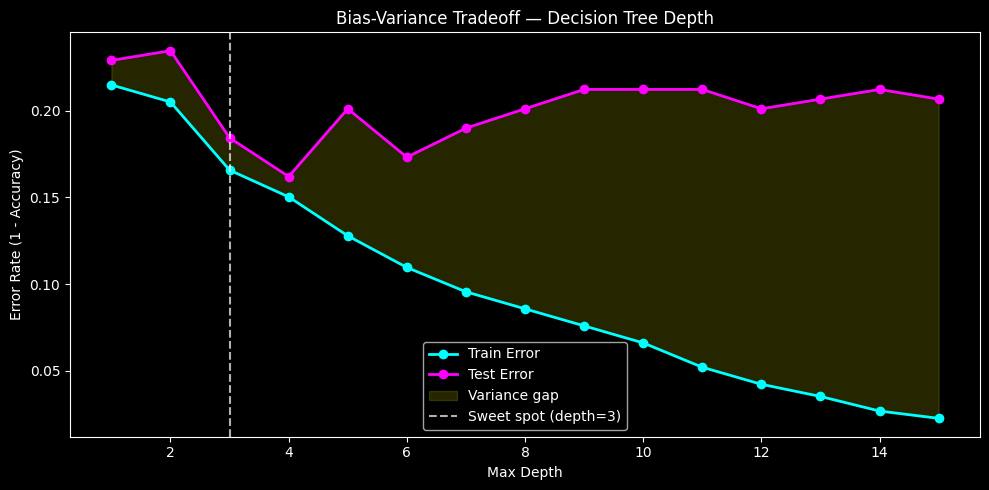


Bias-Variance Summary:
Depth    Train Error    Test Error     Gap (Variance)
-------------------------------------------------------
1        0.2149         0.2291         0.0142 
2        0.2051         0.2346         0.0296 
3        0.1657         0.1844         0.0186 ← sweet spot
4        0.1503         0.1620         0.0117 
5        0.1278         0.2011         0.0733 
6        0.1096         0.1732         0.0636 
7        0.0955         0.1899         0.0944 
8        0.0857         0.2011         0.1154 ← overfit!
9        0.0758         0.2123         0.1364 ← overfit!
10       0.0660         0.2123         0.1463 ← overfit!
11       0.0520         0.2123         0.1603 ← overfit!
12       0.0421         0.2011         0.1590 ← overfit!
13       0.0351         0.2067         0.1716 ← overfit!
14       0.0267         0.2123         0.1856 ← overfit!
15       0.0225         0.2067         0.1842 ← overfit!


In [ ]:
print("=" * 55)
print("       BIAS-VARIANCE TRADEOFF")
print("=" * 55)
print("""
BIAS: Error from wrong assumptions in the model
  High bias → model too SIMPLE → UNDERFITTING
  Misses real patterns in data
  Both train AND test accuracy are low

VARIANCE: Error from sensitivity to training data
  High variance → model too COMPLEX → OVERFITTING
  Memorises training data, fails on new data
  Train accuracy high, test accuracy much lower

THE TRADEOFF:
  Simple model:  High Bias,    Low Variance
  Complex model: Low Bias,     High Variance
  Goal:          Find the sweet spot in between!

TOTAL ERROR = Bias² + Variance + Irreducible Noise

EXAMPLES:
  Decision Tree (depth=None): Low bias, HIGH variance
  Decision Tree (depth=2):    HIGH bias, low variance
  Decision Tree (depth=3):    BALANCED ✅
  Random Forest:              Low bias, LOW variance (best!)
""")

# Demonstrate with Decision Trees at different depths
depths = range(1, 16)
train_errors, test_errors = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_errors.append(1 - dt.score(X_train, y_train))
    test_errors.append(1 - dt.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_errors, "o-", color="cyan", label="Train Error", linewidth=2)
plt.plot(depths, test_errors, "o-", color="magenta", label="Test Error", linewidth=2)
plt.fill_between(
    depths, train_errors, test_errors, alpha=0.15, color="yellow", label="Variance gap"
)
plt.axvline(3, color="white", linestyle="--", alpha=0.7, label="Sweet spot (depth=3)")
plt.title("Bias-Variance Tradeoff — Decision Tree Depth")
plt.xlabel("Max Depth")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nBias-Variance Summary:")
print(f"{'Depth':<8} {'Train Error':<14} {'Test Error':<14} {'Gap (Variance)'}")
print("-" * 55)
for d, tr, te in zip(depths, train_errors, test_errors):
    gap = te - tr
    status = "← sweet spot" if d == 3 else "← overfit!" if gap > 0.1 else ""
    print(f"{d:<8} {tr:<14.4f} {te:<14.4f} {gap:.4f} {status}")

## 3. Learning Curves

           LEARNING CURVES

Learning curves show how model performance changes
as we add MORE training data.

WHAT THEY REVEAL:
  HIGH BIAS (underfitting):
    - Train and CV scores BOTH low
    - Curves converge at a LOW value
    - Adding more data won't help much
    - Fix: more complex model, better features

  HIGH VARIANCE (overfitting):
    - Large GAP between train and CV scores
    - Train score high, CV score lower
    - Curves haven't converged yet
    - Fix: more data, regularisation, simpler model



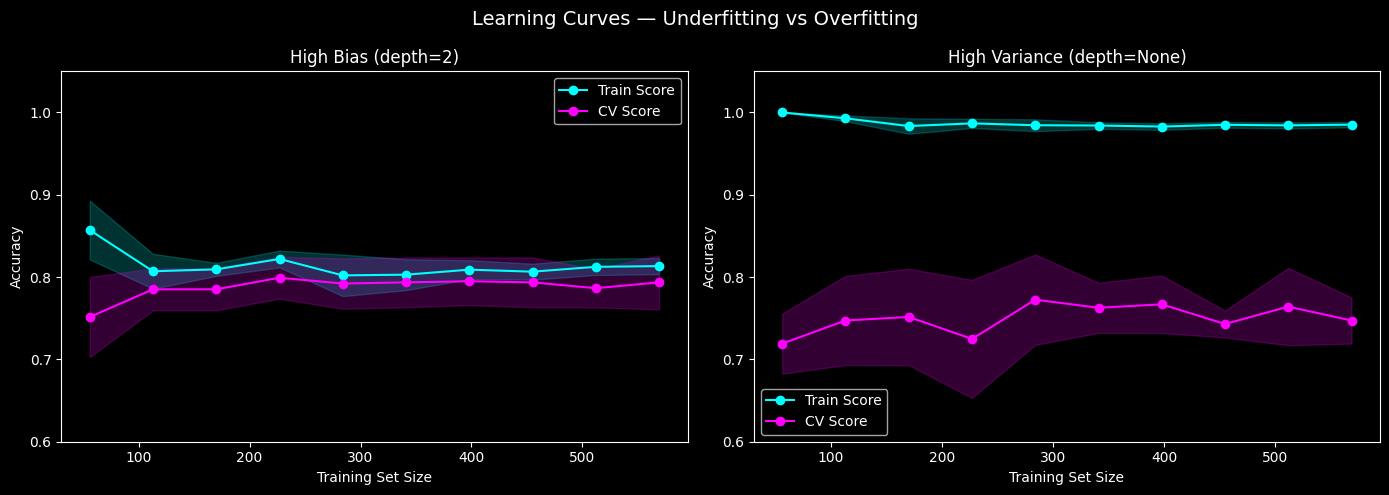


--- Best Model (Random Forest) Learning Curve ---
Train Size   Train AUC    CV AUC       Gap
---------------------------------------------
56           0.9456       0.8199       0.1257
113          0.9506       0.8298       0.1208
170          0.9414       0.8363       0.1051
227          0.9501       0.8514       0.0987
284          0.9463       0.8661       0.0802
341          0.9469       0.8600       0.0869
398          0.9504       0.8688       0.0816
455          0.9526       0.8689       0.0837
512          0.9520       0.8691       0.0829
569          0.9540       0.8738       0.0802


In [ ]:
print("=" * 55)
print("           LEARNING CURVES")
print("=" * 55)
print("""
Learning curves show how model performance changes
as we add MORE training data.

WHAT THEY REVEAL:
  HIGH BIAS (underfitting):
    - Train and CV scores BOTH low
    - Curves converge at a LOW value
    - Adding more data won't help much
    - Fix: more complex model, better features

  HIGH VARIANCE (overfitting):
    - Large GAP between train and CV scores
    - Train score high, CV score lower
    - Curves haven't converged yet
    - Fix: more data, regularisation, simpler model
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Curves — Underfitting vs Overfitting", fontsize=14)

models_to_plot = [
    ("High Bias (depth=2)", DecisionTreeClassifier(max_depth=2, random_state=42)),
    (
        "High Variance (depth=None)",
        DecisionTreeClassifier(max_depth=None, random_state=42),
    ),
]

for ax, (name, model) in zip(axes, models_to_plot):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", color="cyan", label="Train Score")
    ax.plot(train_sizes, val_mean, "o-", color="magenta", label="CV Score")
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
        color="cyan",
    )
    ax.fill_between(
        train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="magenta"
    )
    ax.set_title(name)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.set_ylim(0.6, 1.05)

plt.tight_layout()
plt.show()

# Best model learning curve
print("\n--- Best Model (Random Forest) Learning Curve ---")
rf_best = RandomForestClassifier(n_estimators=100, min_samples_leaf=4, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    rf_best,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
print(f"{'Train Size':<12} {'Train AUC':<12} {'CV AUC':<12} {'Gap'}")
print("-" * 45)
for ts, tr, cv in zip(train_sizes, train_scores.mean(axis=1), val_scores.mean(axis=1)):
    print(f"{ts:<12} {tr:<12.4f} {cv:<12.4f} {tr-cv:.4f}")

## 4. Cross-Validation Strategies

In [ ]:
print("=" * 55)
print("      CROSS-VALIDATION STRATEGIES")
print("=" * 55)

rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=4, random_state=42)

# 1 — Standard K-Fold
from sklearn.model_selection import KFold

kf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
)

# 2 — Stratified K-Fold (keeps class ratio)
skf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
)

# 3 — Repeated K-Fold
from sklearn.model_selection import RepeatedStratifiedKFold

rkf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring="roc_auc",
)

print(f"\n{'CV Strategy':<25} {'Mean AUC':<12} {'Std':<10} {'Min':<10} {'Max'}")
print("-" * 65)
for name, scores in [
    ("KFold (5-fold)", kf_scores),
    ("StratifiedKFold (5-fold)", skf_scores),
    ("Repeated StratKFold (5x3)", rkf_scores),
]:
    print(
        f"{name:<25} {scores.mean():.4f}      {scores.std():.4f}    "
        f"{scores.min():.4f}    {scores.max():.4f}"
    )

print("""
CV STRATEGY GUIDE:
  KFold:              Standard split — may have class imbalance per fold
  StratifiedKFold:    Keeps class ratio per fold — ALWAYS use for classification!
  RepeatedKFold:      Run K-fold N times with different shuffles — more reliable
  LeaveOneOut (LOO):  Each sample is its own test — very expensive, for tiny datasets
  TimeSeriesSplit:    For time series — never use future data to predict past!
""")

print(f"\nStratified vs Non-stratified survival rates per fold:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (_, val_idx) in enumerate(skf.split(X_train, y_train)):
    fold_surv = y_train.iloc[val_idx].mean()
    print(
        f"  Fold {i+1}: {fold_surv:.3f} survival rate (overall: {y_train.mean():.3f})"
    )

      CROSS-VALIDATION STRATEGIES

CV Strategy               Mean AUC     Std        Min        Max
-----------------------------------------------------------------
KFold (5-fold)            0.8787      0.0355    0.8255    0.9276
StratifiedKFold (5-fold)  0.8841      0.0219    0.8680    0.9269
Repeated StratKFold (5x3) 0.8823      0.0245    0.8367    0.9269

CV STRATEGY GUIDE:
  KFold:              Standard split — may have class imbalance per fold
  StratifiedKFold:    Keeps class ratio per fold — ALWAYS use for classification!
  RepeatedKFold:      Run K-fold N times with different shuffles — more reliable
  LeaveOneOut (LOO):  Each sample is its own test — very expensive, for tiny datasets
  TimeSeriesSplit:    For time series — never use future data to predict past!


Stratified vs Non-stratified survival rates per fold:
  Fold 1: 0.385 survival rate (overall: 0.383)
  Fold 2: 0.385 survival rate (overall: 0.383)
  Fold 3: 0.387 survival rate (overall: 0.383)
  Fold 4: 0.380 survi

## 5. Final Model Comparison Framework

     FINAL MODEL COMPARISON FRAMEWORK

               Model  CV_AUC  CV_Acc  Test_AUC  Test_Acc  Precision  Recall     F1
  Gradient Boosting  0.8900  0.8273    0.8361    0.8268     0.8065  0.7246 0.7634
      Random Forest  0.8841  0.8259    0.8492    0.8324     0.8305  0.7101 0.7656
Logistic Regression  0.8675  0.8160    0.8615    0.8156     0.7903  0.7101 0.7481
      Decision Tree  0.8515  0.8217    0.8621    0.8156     0.7571  0.7681 0.7626


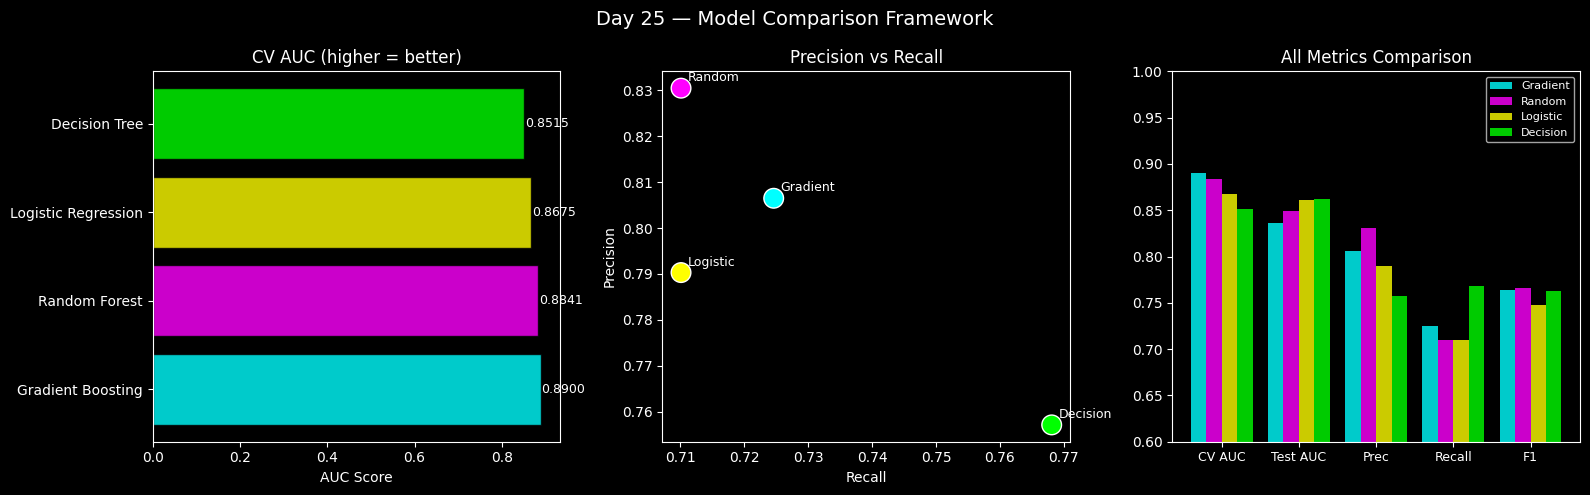

In [ ]:
print("=" * 55)
print("     FINAL MODEL COMPARISON FRAMEWORK")
print("=" * 55)

models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=1.0, random_state=42, max_iter=1000)),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, min_samples_leaf=4, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy").mean()

    results.append(
        {
            "Model": name,
            "CV_AUC": round(cv_auc, 4),
            "CV_Acc": round(cv_acc, 4),
            "Test_AUC": round(roc_auc_score(y_test, y_prob), 4),
            "Test_Acc": round(accuracy_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "F1": round(f1_score(y_test, y_pred), 4),
        }
    )

results_df = pd.DataFrame(results).sort_values("CV_AUC", ascending=False)
print("\n", results_df.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Day 25 — Model Comparison Framework", fontsize=14)

model_names = results_df["Model"].tolist()
colors = ["cyan", "magenta", "yellow", "lime"]

# AUC comparison
axes[0].barh(
    model_names, results_df["CV_AUC"], color=colors, alpha=0.8, edgecolor="black"
)
axes[0].set_title("CV AUC (higher = better)")
axes[0].set_xlabel("AUC Score")
for i, v in enumerate(results_df["CV_AUC"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

# Precision vs Recall
axes[1].scatter(
    results_df["Recall"],
    results_df["Precision"],
    c=colors[: len(results_df)],
    s=200,
    edgecolors="white",
    zorder=5,
)
for i, name in enumerate(model_names):
    row = results_df[results_df["Model"] == name].iloc[0]
    axes[1].annotate(
        name.split()[0],
        (row["Recall"], row["Precision"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )
axes[1].set_title("Precision vs Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

# All metrics radar-style bar chart
metrics = ["CV_AUC", "Test_AUC", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))
width = 0.2
for i, (_, row) in enumerate(results_df.iterrows()):
    axes[2].bar(
        x + i * width,
        [row[m] for m in metrics],
        width,
        label=row["Model"].split()[0],
        color=colors[i],
        alpha=0.8,
    )
axes[2].set_xticks(x + width * 1.5)
axes[2].set_xticklabels(["CV AUC", "Test AUC", "Prec", "Recall", "F1"], fontsize=9)
axes[2].set_title("All Metrics Comparison")
axes[2].legend(fontsize=8)
axes[2].set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

## 6. Key Takeaways — Day 25 🎯

### Bias-Variance Tradeoff
- **Bias:** Error from oversimplification — underfitting
- **Variance:** Error from oversensitivity to data — overfitting
- **Total Error = Bias² + Variance + Irreducible Noise**
- Sweet spot: depth=3 for Decision Tree (train=16.7%, test=18.4%)
- Random Forest: Low bias AND low variance — best of both!

### Reading Learning Curves
| Pattern | Diagnosis | Fix |
|---|---|---|
| Both train+CV low, converging | High Bias (underfitting) | Better model/features |
| Large train-CV gap, not converging | High Variance (overfitting) | More data/regularisation |
| Both high, small gap | Well fitted ✅ | You're done! |

### Cross-Validation Strategies
- **KFold:** Basic — may have class imbalance per fold
- **StratifiedKFold:** ALWAYS use for classification — keeps class ratio
- **RepeatedStratifiedKFold:** More reliable — reduces random variation
- Stratified folds: all had ~38.3% survival rate — perfectly balanced!

### CV Strategies Comparison
- KFold: Mean AUC=0.879, Std=0.036 — higher variance
- StratifiedKFold: Mean AUC=0.884, Std=0.022 — more stable ✅
- RepeatedStratKFold: Mean AUC=0.882, Std=0.025 — most reliable

### Final Model Rankings (CV AUC)
1. Gradient Boosting: 0.890 CV AUC (but lower test!)
2. Random Forest: 0.884 CV AUC, 0.849 Test AUC ✅
3. Logistic Regression: 0.868 CV AUC, 0.862 Test AUC
4. Decision Tree: 0.852 CV AUC

### Model Selection Framework
1. Always use StratifiedKFold for classification
2. Compare CV AUC AND test AUC — gaps reveal overfitting
3. Choose metric based on business need (precision vs recall)
4. Simpler models often generalise better on small datasets
5. Never select model based on test set — use CV!

### sklearn Functions
- `learning_curve(model, X, y, train_sizes, cv, scoring)`
- `validation_curve(model, X, y, param_name, param_range, cv)`
- `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)`
- `cross_val_score(model, X, y, cv=skf, scoring='roc_auc')`